# Applied Mini Project: Customer Churn Prediction

## Business Question

Which customer characteristics are associated with customer churn, and can we use machine learning to predict whether a customer is likely to leave the company?

## Project Goals

This project brings together the data science skills developed during Weeks 1–10:

- Data loading and inspection
- Data cleaning
- Exploratory Data Analysis (EDA)
- Statistical reasoning
- Feature preparation
- Machine learning
- Model evaluation
- Business interpretation
- Data storytelling

## Dataset

The project uses the Telco Customer Churn dataset downloaded from Kaggle. Each row represents a customer and contains information about customer demographics, subscribed services, account information, charges, and whether the customer churned.

## Business Context

Customer churn is an important business problem because losing customers can reduce recurring revenue and increase the cost of acquiring replacement customers. The objective of this mini project is to analyze customer churn and build a classification model that predicts whether a customer will churn.

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### Loading the dataset

In [2]:
file_path = "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# checking the missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Checking the duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Cleaning the total charge
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges converted to numeric.")
print("Missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges converted to numeric.
Missing values in TotalCharges: 11


### Removing the customerID
Because customerID identifies individual customers but isn't a useful predictive feature for our model.

In [9]:
df_clean = df.drop(columns=["customerID"]).copy()

print("Customer ID removed.")
print("Shape:", df_clean.shape)

Customer ID removed.
Shape: (7043, 20)


In [10]:
# Converting the Churn into a machine-learning target
df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df_clean["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [46]:
# Checking the cleaned dataset
print(df_clean.head())
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [12]:
print("Final dataset shape:", df_clean.shape)

Final dataset shape: (7043, 20)


## 2. Data Cleaning

The dataset was inspected for missing values, duplicate records, incorrect data types, and unnecessary identifiers.
    The following cleaning steps were performed:

1. Converted `TotalCharges` from text to numeric format.
2. Invalid or blank values in `TotalCharges` were converted to missing values.
3. Checked for duplicate rows.
4. Removed `customerID` because it is an identifier rather than a predictive feature.
5. Converted the target variable `Churn` from `Yes/No` into binary values:
   - `0` = No churn
   - `1` = Churn

Missing values will be handled through the machine-learning preprocessing pipeline.

## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution of customer churn and identify patterns between churn and important customer characteristics.

The analysis focuses on:

- Overall churn distribution
- Customer contract type
- Internet service type
- Payment method
- Customer tenure
- Monthly charges

In [15]:
churn_counts = df_clean["Churn"].value_counts().sort_index()

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(df_clean["Churn"].value_counts(normalize=True).sort_index() * 100)

Churn counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn percentages:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


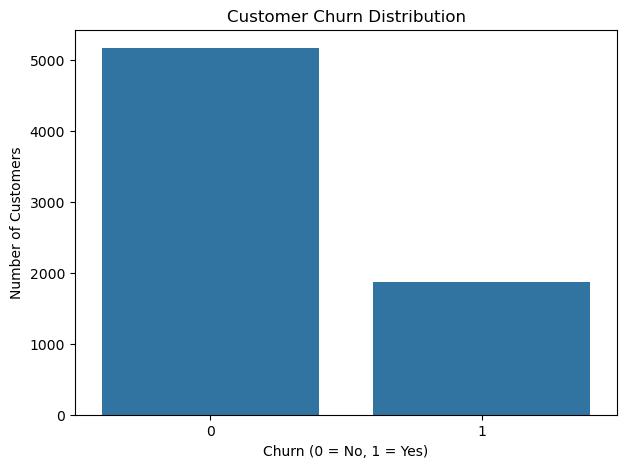

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
churn_rate = df_clean["Churn"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


### Overall Churn Rate

The overall churn rate represents the percentage of customers in the dataset who have churned. This provides a baseline understanding of the customer retention situation before examining individual customer characteristics.

### Churn by Contract Type

Contract type is examined because customers with different contract commitments may have different retention patterns.

In [18]:
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


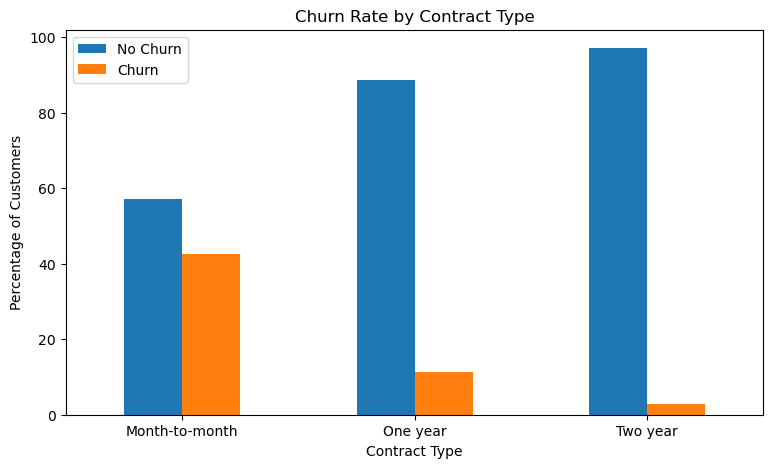

In [19]:
contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.legend(["No Churn", "Churn"])

plt.xticks(rotation=0)
plt.show()

### Interpretation

The churn rate differs across contract types.
Customers on shorter-term contracts show a different churn pattern from customers on longer-term contracts. This suggests that contract commitment is an important variable to consider when studying customer retention.
The analysis shows an association between contract type and churn, but it does not by itself prove that contract type causes customers to leave.

### Churn by Internet Service

Internet service type is examined to determine whether churn patterns differ between customers using different internet services.

In [20]:
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,0,1
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


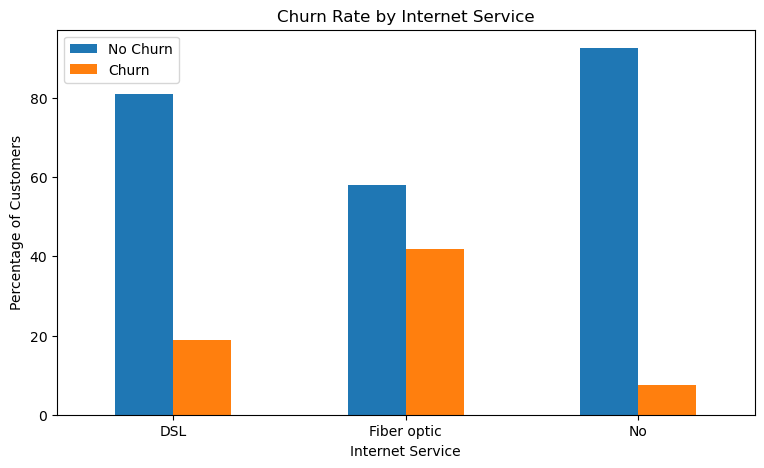

In [47]:
internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.legend(["No Churn", "Churn"])
plt.xticks(rotation=0)

plt.show()

### Interpretation

Churn rates vary across internet service categories.

This indicates that the type of internet service is associated with customer retention behavior and may provide useful information for a churn prediction model.

### Churn by Payment Method

Payment method is examined to identify differences in churn patterns across customer payment preferences.

In [22]:
payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


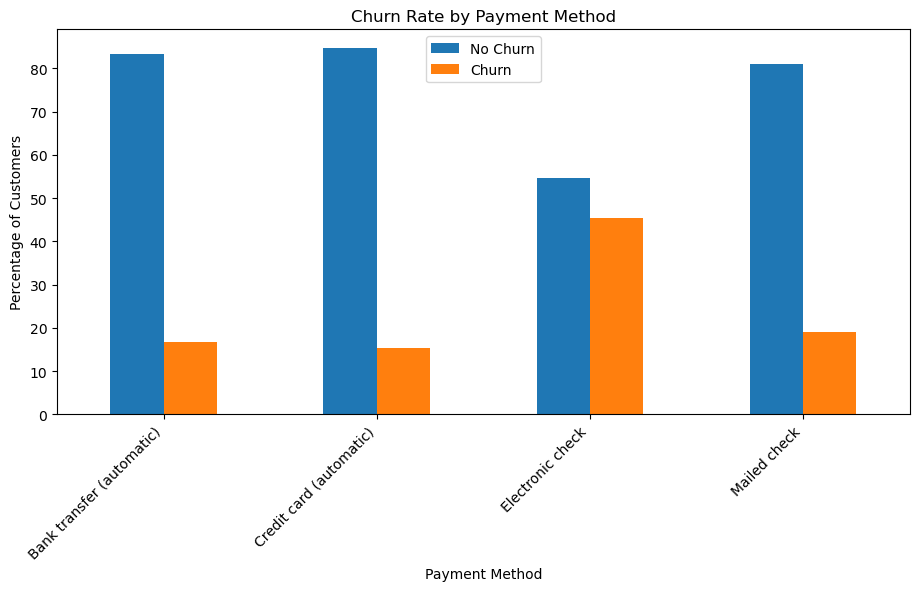

In [24]:
payment_churn.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.legend(["No Churn", "Churn"])

plt.xticks(rotation=45, ha="right")
plt.show()

### Interpretation

The churn rate differs between payment methods.

Payment method may therefore contain useful information for predicting churn. However, these differences should be interpreted as associations rather than evidence that the payment method itself directly causes churn.

### Customer Tenure and Churn

Customer tenure represents the number of months a customer has been with the company.

We examine tenure because customer retention patterns may differ between newer and longer-term customers.

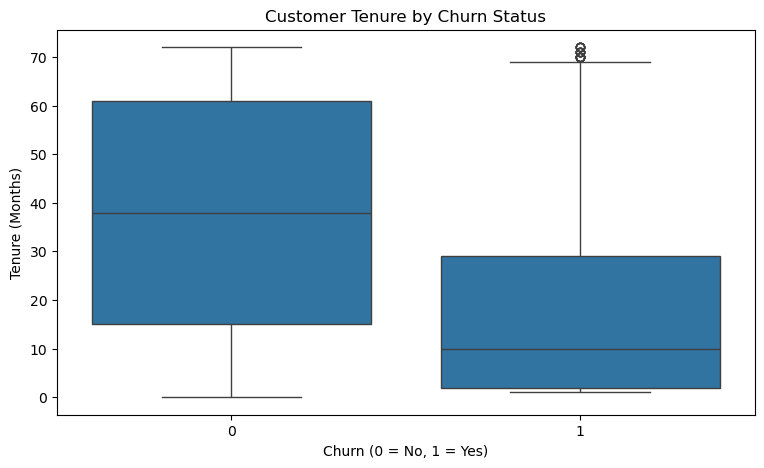

In [25]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (Months)")

plt.show()

In [27]:
df_clean.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


### Interpretation

The tenure distributions show a difference between customers who churned and those who remained.

Tenure is therefore a potentially useful predictive feature because it captures how long customers have maintained their relationship with the company.

### Monthly Charges and Churn

Monthly charges are examined to determine whether customers with different monthly billing levels show different churn patterns.

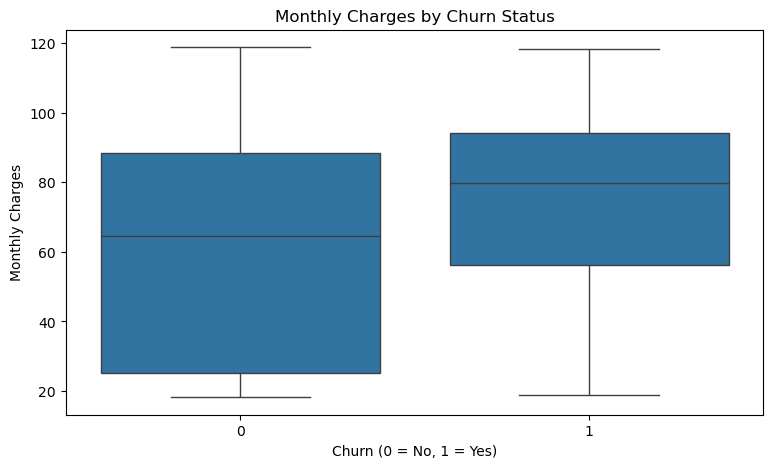

In [28]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")

plt.show()

In [29]:

df_clean.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


### Interpretation

The distribution of monthly charges differs between churn groups.

Monthly charges may therefore provide useful information for predicting customer churn.

##  EDA Summary

The exploratory analysis identified several customer characteristics that are associated with differences in churn rates.

The main observations include:

- Customer churn is not evenly distributed across the dataset.
- Churn patterns differ across contract types.
- Churn rates vary across internet service categories.
- Payment methods show different churn patterns.
- Customer tenure differs between churned and retained customers.
- Monthly charges also show differences between churn groups.

These findings help identify potentially useful predictors for the machine-learning model.

However, the EDA findings describe associations in the observed data and should not be interpreted as proof of causal relationships.

## 4. Machine Learning — Customer Churn Prediction

A Logistic Regression model will be used to predict whether a customer will churn.

Logistic Regression is appropriate because the target variable is binary:

- `0` = No churn
- `1` = Churn

The preprocessing pipeline will handle numerical and categorical variables separately.

In [30]:
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 19)
Target shape: (7043,)


In [31]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [32]:
# Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 19)
Testing set: (1409, 19)


In [34]:
# Building preprocessing pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [35]:
# Building  the Logistic Regression model
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

print("Machine learning pipeline created successfully.")

Machine learning pipeline created successfully.


In [36]:
# training the model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [37]:
# make the predictions
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 5. Model Evaluation

The model will be evaluated using several metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Using multiple metrics is important because churn prediction involves an imbalanced target variable and different types of prediction errors have different business implications.

In [38]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-score : 0.6040
ROC-AUC  : 0.8419


In [39]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



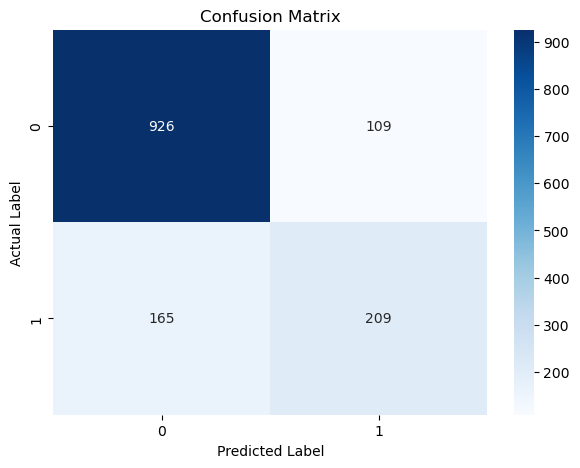

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows four possible outcomes:

- **True Negative:** Customer did not churn and the model predicted no churn.
- **False Positive:** Customer did not churn but the model predicted churn.
- **False Negative:** Customer churned but the model predicted no churn.
- **True Positive:** Customer churned and the model correctly predicted churn.

These results help explain the types of prediction errors made by the model.

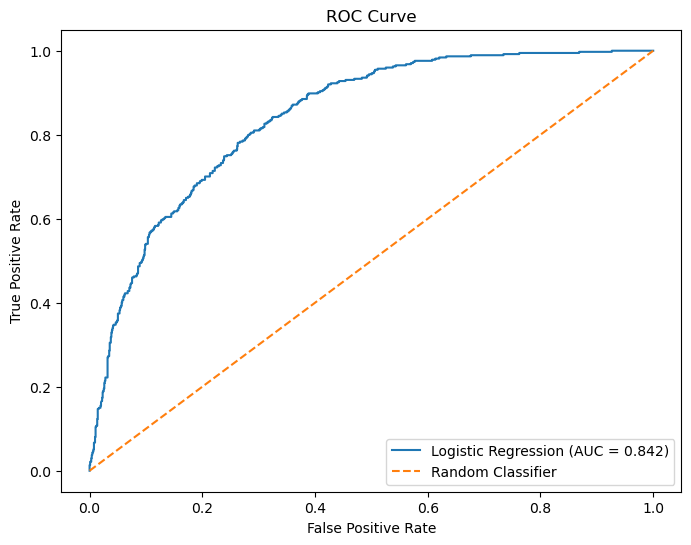

In [42]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### ROC-AUC Interpretation

The ROC curve shows the relationship between the true positive rate and false positive rate at different classification thresholds.

The ROC-AUC value summarizes the model's ability to distinguish between customers who churn and customers who do not churn.

A higher ROC-AUC indicates better separation between the two classes, although model performance should be considered together with the other evaluation metrics.

In [43]:
# Identifying important model coefficients
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["AbsoluteCoefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,AbsoluteCoefficient
1,num__tenure,-1.241319,1.241319
38,cat__Contract_Two year,-0.772261,0.772261
15,cat__InternetService_DSL,-0.652406,0.652406
16,cat__InternetService_Fiber optic,0.640026,0.640026
2,num__MonthlyCharges,-0.596392,0.596392
36,cat__Contract_Month-to-month,0.579304,0.579304
3,num__TotalCharges,0.516708,0.516708
39,cat__PaperlessBilling_No,-0.343260,0.343260
22,cat__OnlineBackup_No internet service,-0.301082,0.301082
17,cat__InternetService_No,-0.301082,0.301082


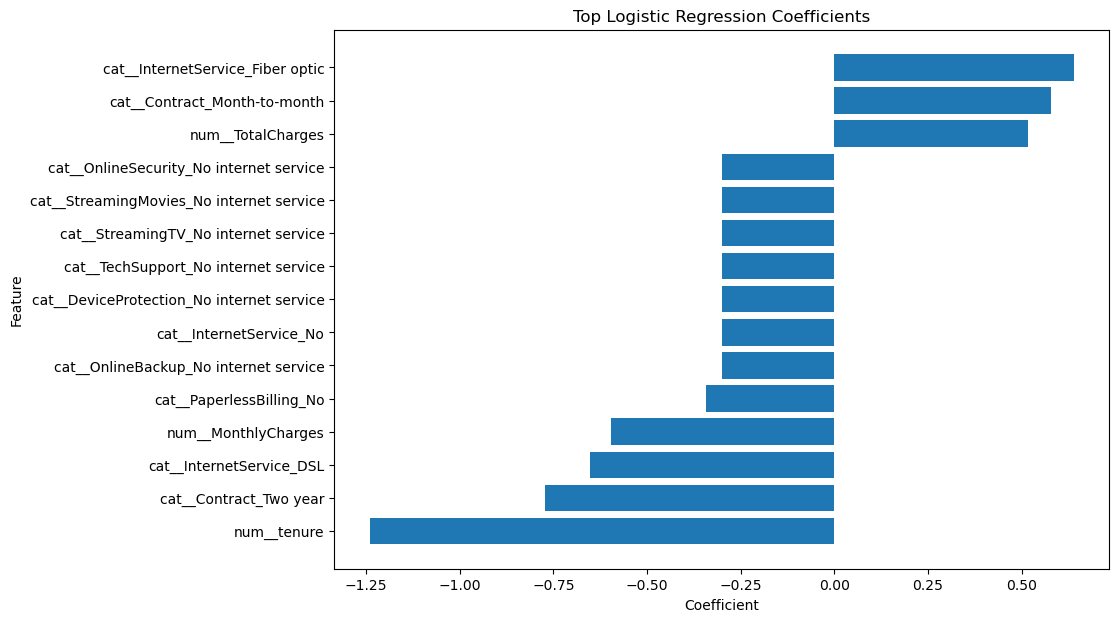

In [44]:
# Visualizing important coefficients 
top_features = feature_importance.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Model Interpretation

The Logistic Regression coefficients provide an indication of how individual encoded features are associated with the predicted probability of churn.

Positive coefficients are associated with higher predicted odds of churn, while negative coefficients are associated with lower predicted odds of churn, holding the other model variables constant.

These coefficients should be interpreted as model associations rather than proof of causal effects.

## 6. Business Interpretation

The analysis shows that customer churn is associated with several customer characteristics, including contract type, tenure, monthly charges, internet service, and payment method.
The machine-learning model provides a way to identify customers who may be at higher risk of churn based on the information available in the dataset.
From a business perspective, a churn prediction system could support customer-retention activities by helping a company identify customers who may need additional attention.
For example, a business could use churn-risk predictions as one input when deciding which customers should receive retention offers, service reviews, or customer-support follow-ups.
However, the model should be treated as a decision-support tool rather than an automatic decision-maker. Predictions are based on historical data and may contain errors or reflect patterns specific to this dataset.
The model's precision, recall, F1-score, ROC-AUC, and confusion matrix should therefore be considered before using predictions in a real business process.

## 7. Plain-Language Project Conclusion

Customer churn is an important business problem because losing customers can reduce recurring revenue and increase the cost of acquiring new customers.
In this project, the customer dataset was cleaned and explored to understand patterns associated with churn. The analysis found differences in churn patterns across customer characteristics such as contract type, tenure, monthly charges, internet service, and payment method.
A Logistic Regression classification model was then trained to predict whether a customer would churn.
The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, classification results, a confusion matrix, and an ROC curve.

Overall, the project demonstrates how data science can combine data cleaning, exploratory analysis, machine learning, and business communication to investigate a practical customer-retention problem.
The results should be considered as analytical evidence from this dataset rather than a guarantee that the same patterns will occur for every customer or future dataset.

## 8. Limitations

This project has several limitations:

1. The analysis uses a single customer churn dataset, so the findings may not generalize to every company or industry.

2. The dataset represents historical customer behavior. Future customer behavior may differ.

3. The Logistic Regression model captures relationships in the available variables but does not establish causal relationships.

4. The model can make both false-positive and false-negative predictions.

5. Some potentially important business variables may not be included in the dataset.

6. The model has not been tested on a separate external dataset.

7. Additional models, hyperparameter tuning, cross-validation, and threshold optimization could be explored in a future project.

Therefore, the model should be viewed as a starting point for churn analysis rather than a complete production-ready churn prediction system.

## 9. Mentor Feedback

### Initial Feedback Status

**Status: Pending**

Initial mentor feedback will be requested after completion of this mini project.

### Feedback Received

_To be completed after mentor review._

### Changes Made Based on Feedback

_To be completed after mentor feedback is received._

## 10. Final Summary

This mini project brought together the main data science skills developed during the internship:

- Python programming
- Pandas data manipulation
- Data cleaning
- Exploratory Data Analysis
- Data visualization
- Statistical reasoning
- Feature preprocessing
- Machine learning
- Classification
- Model evaluation
- Business interpretation
- Communication of analytical findings

The complete workflow starts with raw customer data and ends with a machine-learning model and a plain-language business conclusion.